# EDA

In [26]:
import pandas as pd

In [27]:
df = pd.read_csv("cleaned_transactions.csv")

In [28]:
df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)

,is_fraud
is_fraud,1.000000
txn_velocity_24h,0.759501
txn_velocity_1h,0.698406
risk_score_internal,0.612034
ip_risk_score,0.591922
chargeback_history_count,0.584741
location_mismatch,0.429509
new_device,0.388591
corridor_risk,0.198640
exchange_rate_src_to_dest,0.155145


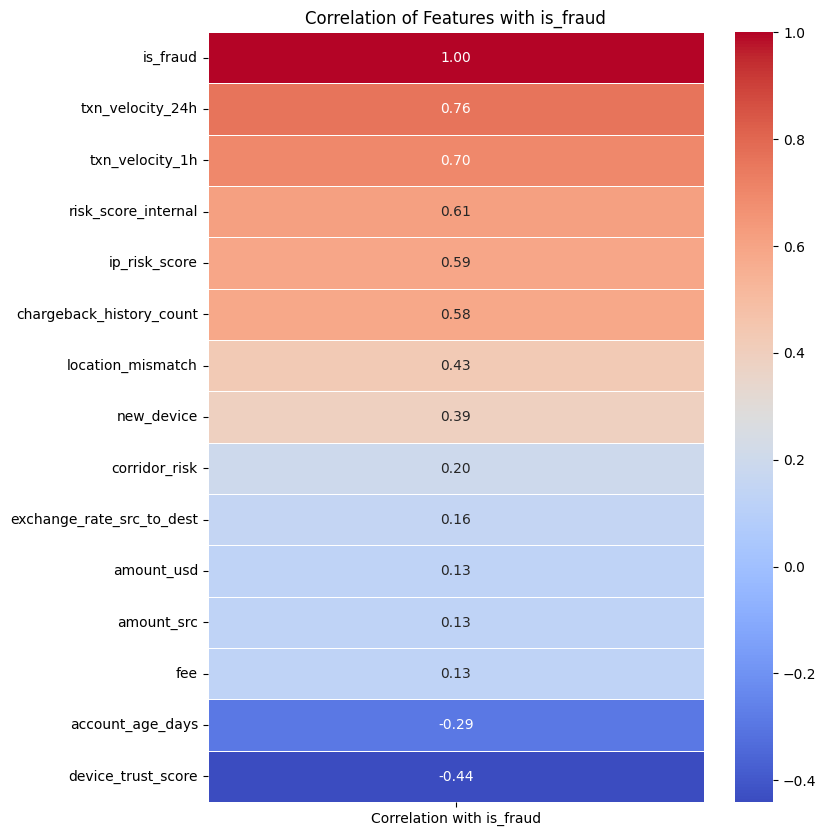

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the correlation series from the previous cell's output
correlation_series = df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)

# Convert the series to a DataFrame for heatmap plotting
correlation_df = correlation_series.to_frame(name='Correlation with is_fraud')

# Create a heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Features with is_fraud')
plt.yticks(rotation=0)
plt.show()

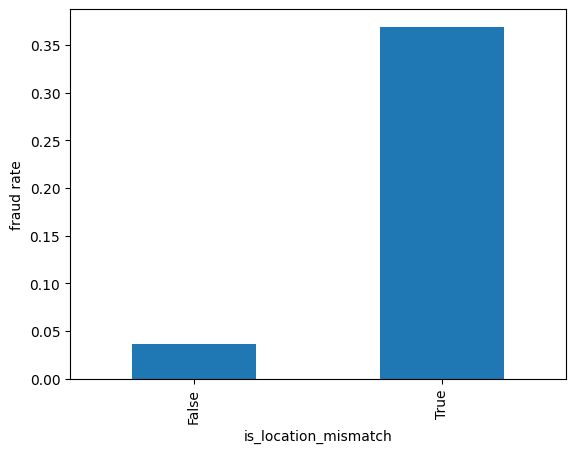

In [30]:
df.groupby("location_mismatch")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("is_location_mismatch")
plt.show()

In [31]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
cat_cols

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'device_id',
       'ip_address', 'ip_country', 'kyc_tier', 'home_country_cleaned'],
      dtype='object')

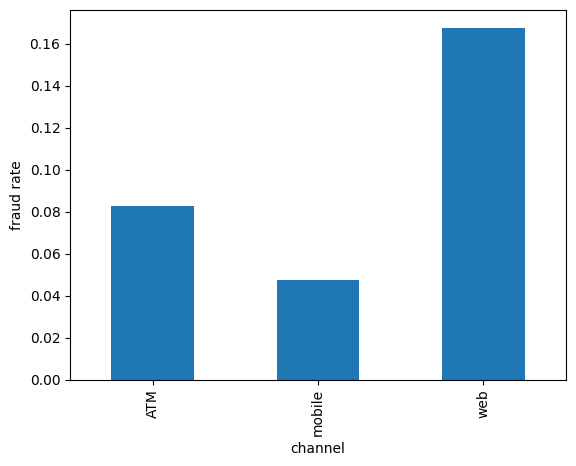

In [32]:
df.groupby("channel")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("channel")
plt.show()

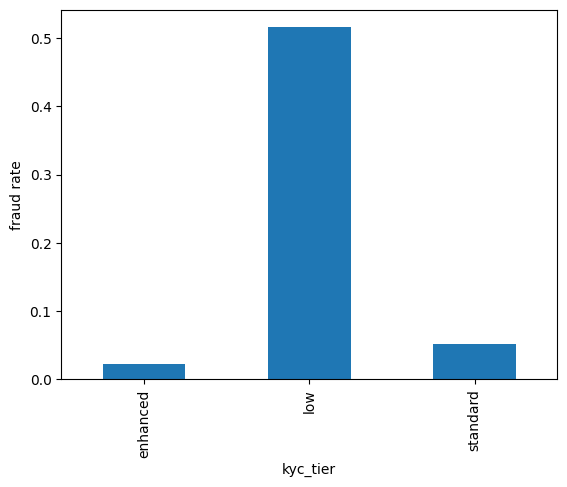

In [33]:
df.groupby("kyc_tier")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("kyc_tier")
plt.show()

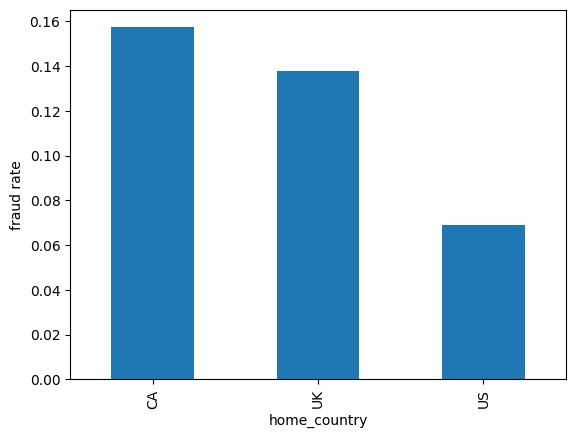

In [34]:
df.groupby("home_country_cleaned")["is_fraud"].mean().plot.bar()
plt.ylabel("fraud rate")
plt.xlabel("home_country")
plt.show()

# Feature Engineering

In [38]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [40]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = (df['timestamp'].dt.dayofweek >= 5).astype(int)

In [42]:
fraud_by_hour = df.groupby('hour')['is_fraud'].mean()
fraud_by_day_of_week = df.groupby('day_of_week')['is_fraud'].mean()
fraud_by_month = df.groupby('month')['is_fraud'].mean()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

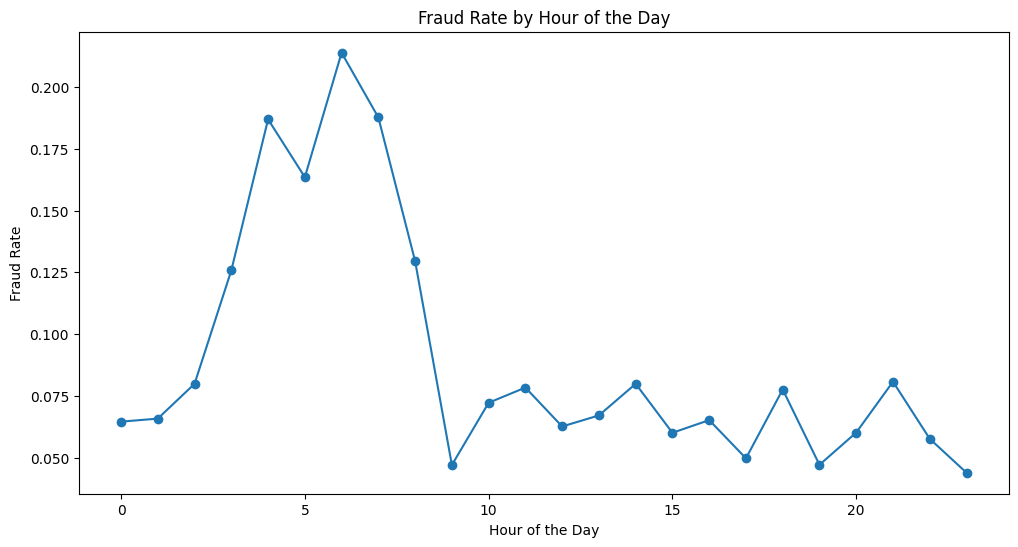

In [43]:
plt.figure(figsize=(12, 6))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour of the Day')
plt

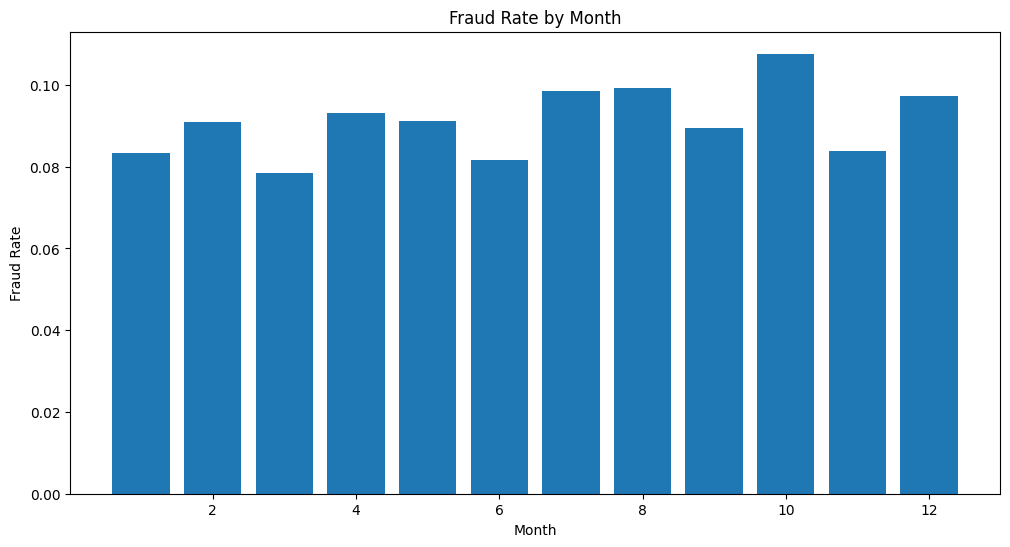

In [46]:
plt.figure(figsize=(12, 6))
plt.bar(fraud_by_month.index, fraud_by_month.values)
plt.xlabel('Month')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Month')
plt.show()

In [56]:
df['account_age_days'].describe()

,account_age_days
count,10757.000000
mean,393.076508
std,342.046871
min,1.000000
25%,147.000000
50%,281.000000
75%,661.000000
max,1095.000000


In [52]:
bins = [0, 30, 90, 365, float('inf')]
labels = ['<30 days', '30-90 days', '91-365 days', '>365 days']
df['account_age_bucket'] = pd.cut(df['account_age_days'], bins=bins, labels=labels, right=False)

In [51]:
fraud_rate_by_bucket = df.groupby('account_age_bucket', observed=False)['is_fraud'].mean().reset_index()
print("Fraud rate by account age bucket calculated successfully.")

Fraud rate by account age bucket calculated successfully.


In [53]:
overall_fraud_rate = df['is_fraud'].mean()
print(f"Overall fraud rate calculated: {overall_fraud_rate}")

Overall fraud rate calculated: 0.09128939295342568


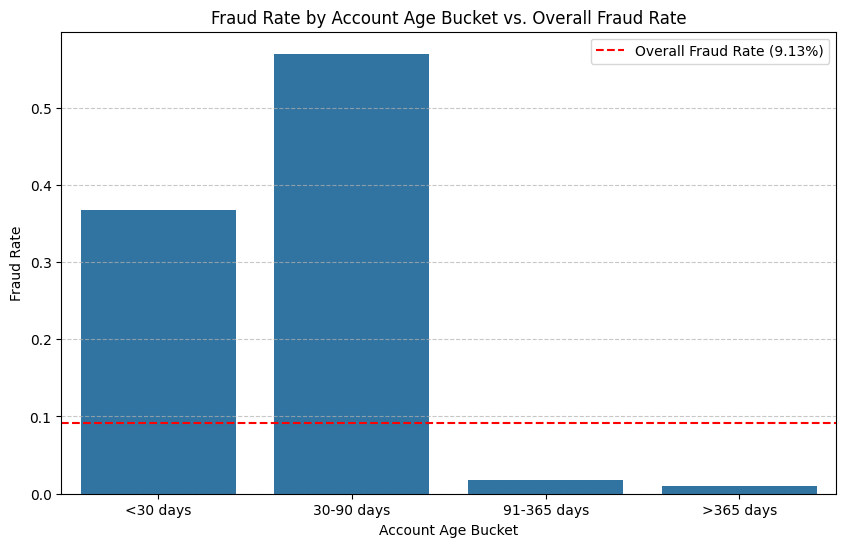

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='account_age_bucket', y='is_fraud', data=fraud_rate_by_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by Account Age Bucket vs. Overall Fraud Rate')
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

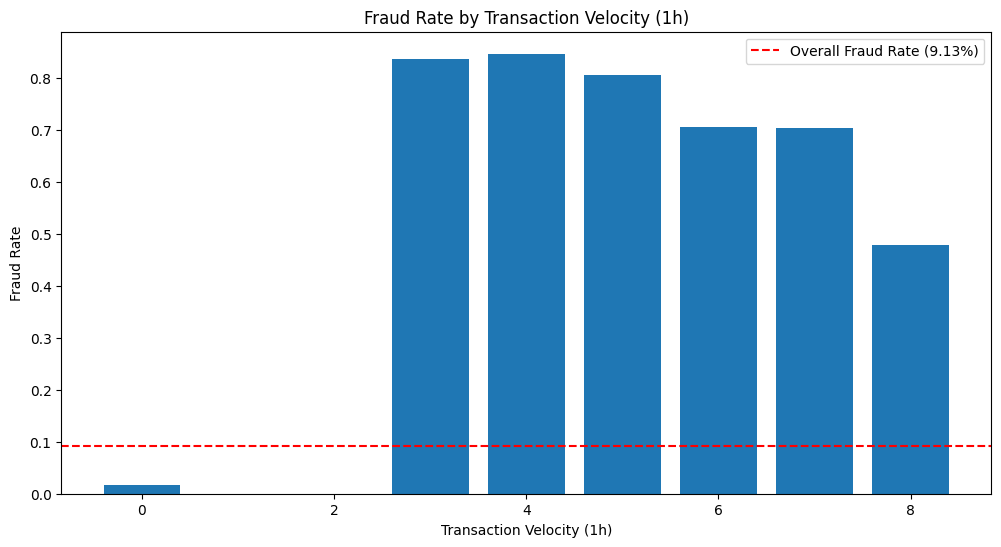

In [58]:
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()

plt.figure(figsize=(12, 6))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values)
plt.xlabel('Transaction Velocity (1h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (1h)')
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.legend()
plt.show()

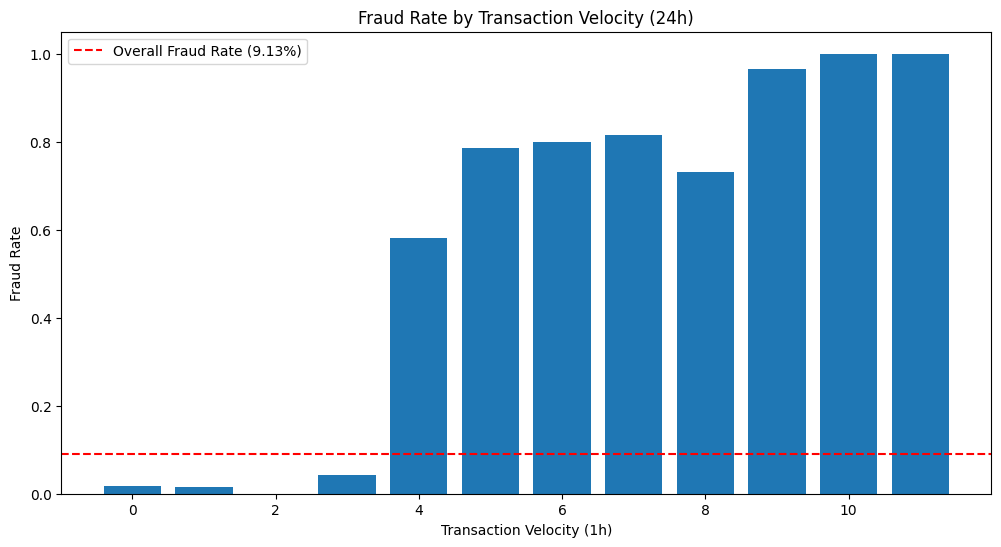

In [62]:
fraud_by_24velocity = df.groupby('txn_velocity_24h')['is_fraud'].mean()

plt.figure(figsize=(12, 6))
plt.bar(fraud_by_24velocity.index, fraud_by_24velocity.values)
plt.xlabel('Transaction Velocity (1h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (24h)')
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.legend()
plt.show()

In [66]:
bins = [0, 100, 500, 1000, 2000, 5000, float('inf')]
labels = ['<100', '100-500', '500-1000', '1000-2000', '2000-5000', '>5000']
df['amount_bucket'] = pd.cut(df['amount_usd'], bins=bins, labels=labels, right=False)

In [67]:
fraud_rate_by_amount_bucket = df.groupby('amount_bucket', observed=False)['is_fraud'].mean().reset_index()

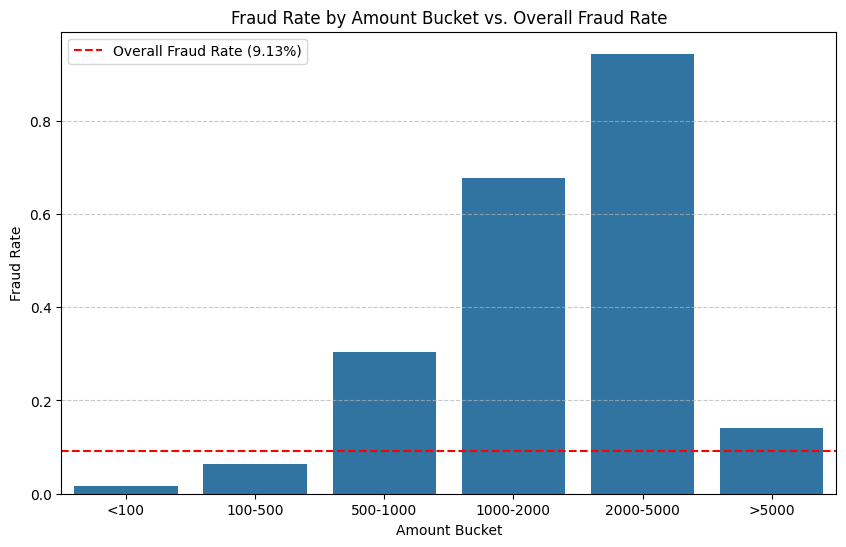

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(x='amount_bucket', y='is_fraud', data=fraud_rate_by_amount_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by Amount Bucket vs. Overall Fraud Rate')
plt.xlabel('Amount Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [69]:
bins = [0, 0.3, 0.5, 0.7, 0.8, 1.0]
labels = ['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.8', '>0.8']
df['ip_risk_score_bucket'] = pd.cut(df['ip_risk_score'], bins=bins, labels=labels, right=False)

In [72]:
fraud_rate_by_ip_risk_bucket = df.groupby('ip_risk_score_bucket', observed=False)['is_fraud'].mean().reset_index()

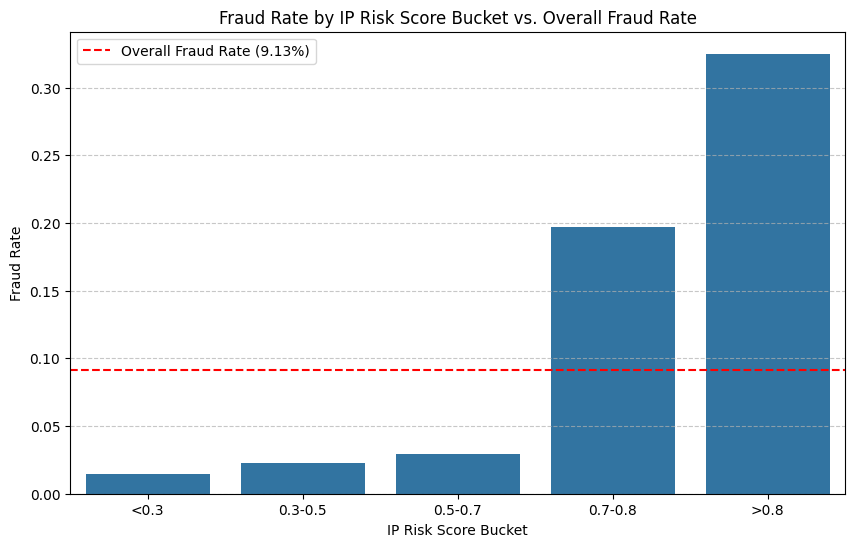

In [71]:
plt.figure(figsize=(10, 6))
sns.barplot(x='ip_risk_score_bucket', y='is_fraud', data=fraud_rate_by_ip_risk_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by IP Risk Score Bucket vs. Overall Fraud Rate')
plt.xlabel('IP Risk Score Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [73]:
bins = [0, 0.3, 0.5, 0.7, 0.8, 1.0]
labels = ['<0.3', '0.3-0.5', '0.5-0.7', '0.7-0.8', '>0.8']
df['device_trust_score_bucket'] = pd.cut(df['device_trust_score'], bins=bins, labels=labels, right=False)

In [76]:
fraud_rate_by_device_trust_bucket = df.groupby('device_trust_score_bucket', observed=False)['is_fraud'].mean().reset_index()


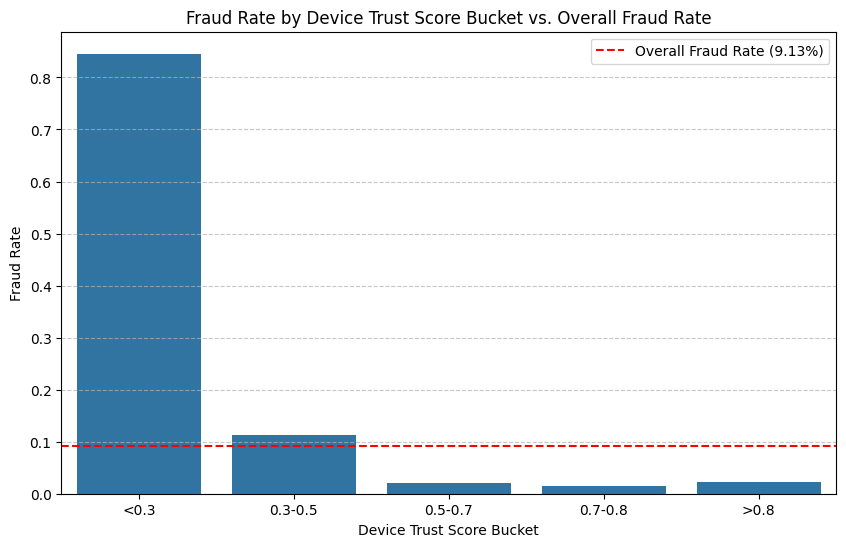

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(x='device_trust_score_bucket', y='is_fraud', data=fraud_rate_by_device_trust_bucket)
plt.axhline(y=overall_fraud_rate, color='r', linestyle='--', label=f'Overall Fraud Rate ({overall_fraud_rate:.2%})')
plt.title('Fraud Rate by Device Trust Score Bucket vs. Overall Fraud Rate')
plt.xlabel('Device Trust Score Bucket')
plt.ylabel('Fraud Rate')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df['night_hours'] = ((df['hour'] >= 3) & (df['hour'] <= 7)).astype(int)

In [77]:
bins = [0, 30, 90, float('inf')]
labels = ['very new', 'relatively new', 'matured']
df['account_age_breakdown'] = pd.cut(df['account_age_days'], bins=bins, labels=labels, right=False)
print("Created 'account_age_breakdown' column successfully.")

Created 'account_age_breakdown' column successfully.


In [78]:
bins = [0, 500, 2000, 5000, float('inf')]
labels = ['low', 'mid', 'high', 'very high']
df['amount_breakdown'] = pd.cut(df['amount_usd'], bins=bins, labels=labels, right=False)
print("Created 'amount_breakdown' column successfully.")

Created 'amount_breakdown' column successfully.


In [79]:
bins = [0, 0.3, 0.6, float('inf')]
labels = ['low', 'medium', 'high']
df['ip_risk'] = pd.cut(df['ip_risk_score'], bins=bins, labels=labels, right=False)
print("Created 'ip_risk' column successfully.")

Created 'ip_risk' column successfully.


In [80]:
bins = [0, 0.3, 0.6, float('inf')]
labels = ['low', 'medium', 'high']
df['device_risk'] = pd.cut(df['device_trust_score'], bins=bins, labels=labels, right=False)
print("Created 'device_risk' column successfully.")

Created 'device_risk' column successfully.


In [81]:
df.to_csv('engineered_features.csv', index=False)
print("DataFrame with engineered features saved to 'engineered_features.csv'.")

DataFrame with engineered features saved to 'engineered_features.csv'.
